In [16]:
!pip install legacy-cgi
!pip install opendatasets
import opendatasets as od

od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

Skipping, found downloaded files in "./rice-type-classification" (use force=True to force download)


In [25]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [26]:
data_df = pd.read_csv("/content/rice-type-classification/riceClassification.csv")
data_df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [52]:
data_df.sample(1)

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
9240,0.684623,0.930172,0.641684,0.98313,0.650436,0.827419,0.765168,0.732425,0.699895,0.822416,1.0


In [27]:
data_df.dropna(inplace = True)
data_df.drop(['id'], axis = 1, inplace = True)
print(data_df.shape)

(18185, 11)


In [28]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [29]:
print(data_df['Class'].value_counts())

Class
1    9985
0    8200
Name: count, dtype: int64


In [30]:
original = data_df.copy()

for column in data_df.columns:
  data_df[column]= data_df[column]/data_df[column].abs().max()

In [31]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [32]:
X = np.array(data_df.iloc[:,:-1])
Y = np.array(data_df.iloc[:,-1])

In [33]:
X_train, X_test , y_train , y_test = train_test_split(X ,Y ,test_size = 0.3)


In [34]:
X_test , X_val , y_test , y_val = train_test_split(X_test,y_test,test_size=0.5)

In [37]:
class dataset(Dataset):
  def __init__(self,X,Y):
    self.X = torch.tensor(X, dtype = torch.float32).to(device)
    self.Y = torch.tensor(Y, dtype = torch.float32).to(device)
  def __len__(self):
    return len(self.X)
  def __getitem__(self, index):
    return self.X[index] , self.Y[index]

In [38]:
training_data = dataset(X_train,y_train)
validation_data = dataset(X_val, y_val)
testing_data = dataset(X_test, y_test)

In [39]:
train_dataloader = DataLoader(training_data, batch_size =8,shuffle = True)
validation_dataloader = DataLoader(validation_data, batch_size = 8, shuffle = True)
testing_dataloader = DataLoader(testing_data , batch_size = 8, shuffle = True)

In [40]:
import torch
import torch.nn as nn

HIDDEN_NEURONS = 10

class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()

        self.input_layer = nn.Linear(X.shape[1], HIDDEN_NEURONS)
        self.linear = nn.Linear(HIDDEN_NEURONS, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.input_layer(x)
        x = self.linear(x)
        x = self.sigmoid(x)
        return x

model = MyModel().to(device)

In [41]:
!pip install torchinfo
from torchinfo import summary
summary(model,(X.shape[1],))

Layer (type:depth-idx)                   Output Shape              Param #
MyModel                                  [1]                       --
├─Linear: 1-1                            [10]                      110
├─Linear: 1-2                            [1]                       11
├─Sigmoid: 1-3                           [1]                       --
Total params: 121
Trainable params: 121
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [42]:
from torch.optim import Adam
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr = 1e-3)

In [43]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

epochs = 10
for epoch in range(epochs):
  total_acc_train = 0
  total_loss_train = 0
  total_acc_val = 0
  total_loss_val = 0

  for data in train_dataloader:

    inputs, labels = data

    prediction = model(inputs).squeeze(1)

    batch_loss = criterion(prediction,labels)

    total_loss_train += batch_loss.item()

    acc = ((prediction).round() == labels).sum().item()
    #total_acc_train += acc
    total_acc_train += acc
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  with torch.no_grad():
    for data in validation_dataloader:
      inputs,labels = data

      prediction = model(inputs).squeeze(1)
      batch_loss = criterion(prediction, labels)

      total_loss_val += batch_loss.item()
      acc = ((prediction.round()) == labels).sum().item()

      total_acc_val += acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))

  total_acc_train_plot.append(round(total_acc_train/(training_data.__len__())*100, 4))
  total_acc_validation_plot.append(round(total_acc_val/(validation_data.__len__())*100, 4))

  print(f'''Epoch no. {epoch+1} Train Loss : {round(total_loss_train/1000, 4)} Train Accuracy {round(total_acc_train/training_data.__len__()*100 , 4)}
        Validation Loss : {round(total_loss_val/1000,4)} Validation Accuracy: {round(total_acc_val/(training_data.__len__())*100,4)}''')
  print("="*25)

Epoch no. 1 Train Loss : 0.7039 Train Accuracy 87.6345
        Validation Loss : 0.0522 Validation Accuracy: 21.1564
Epoch no. 2 Train Loss : 0.1521 Train Accuracy 98.3738
        Validation Loss : 0.0203 Validation Accuracy: 21.1878
Epoch no. 3 Train Loss : 0.0882 Train Accuracy 98.5545
        Validation Loss : 0.0147 Validation Accuracy: 21.18
Epoch no. 4 Train Loss : 0.076 Train Accuracy 98.5309
        Validation Loss : 0.0132 Validation Accuracy: 21.1721
Epoch no. 5 Train Loss : 0.0696 Train Accuracy 98.6095
        Validation Loss : 0.0126 Validation Accuracy: 21.1643
Epoch no. 6 Train Loss : 0.0679 Train Accuracy 98.6252
        Validation Loss : 0.0168 Validation Accuracy: 21.0779
Epoch no. 7 Train Loss : 0.0681 Train Accuracy 98.6409
        Validation Loss : 0.0122 Validation Accuracy: 21.1721
Epoch no. 8 Train Loss : 0.0671 Train Accuracy 98.5781
        Validation Loss : 0.0122 Validation Accuracy: 21.1721
Epoch no. 9 Train Loss : 0.067 Train Accuracy 98.5545
        Valid

In [44]:
import torch
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for data in testing_dataloader:
    inputs, labels = data

    prediction = model(inputs).squeeze(1)

    batch_loss_test = criterion((prediction), labels)
    total_loss_test += batch_loss_test.item()
    acc = ((prediction).round() == labels).sum().item()
    total_acc_test += acc
print(f"Accuracy Score is : {round((total_acc_test/X_test.shape[0])*100, 2)}%")

Accuracy Score is : 98.64%


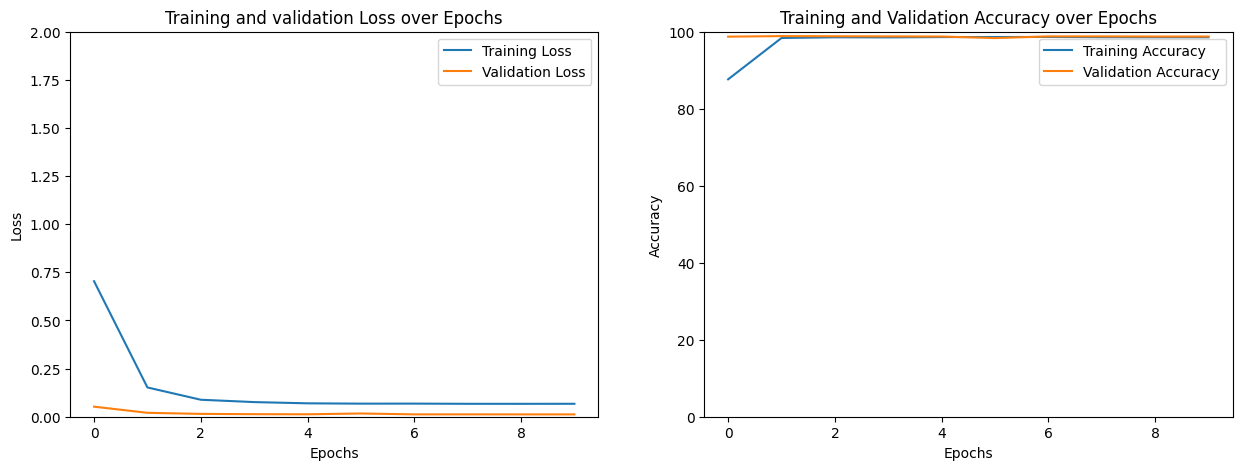

In [45]:
fig ,axs = plt.subplots(nrows =1, ncols =2, figsize =(15,5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim([0, 2])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0, 100])
axs[1].legend()

In [56]:
area = float(input("Area:"))/original['Area'].abs().max()

MajorAxisLength = float(input("Major Axis length:"))/original['MajorAxisLength'].abs().max()

MinorAxisLength = float(input("Minor Axis length"))/original['MinorAxisLength'].abs().max()

Eccentricity = float(input("Eccentricity: "))/original['Eccentricity'].abs().max()

ConvexArea = float(input("Conves Area:"))/original['ConvexArea'].abs().max()

EquivDiameter = float(input("Equivdiameter: "))/original['EquivDiameter'].abs().max()

Extent = float(input("Extent:"))/original['Perimeter'].abs().max()

Perimeter = float(input("Perimeter:"))/original['Perimeter'].abs().max()

Roundness = float(input("Roundness:"))/original['Roundness'].abs().max()


AspectRation = float(input("Aspectration"))/original['AspectRation'].abs().max()

my_inputs = [area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea, EquivDiameter, Extent, Perimeter, Roundness, AspectRation ]

print("="*20)
model_inputs = torch.Tensor(my_inputs).to(device)
prediction = (model(model_inputs))
print(prediction)
print("Class is: ", round(prediction.item()))



Area:85.124785
Major Axis length:56.374021
Minor Axis length0.641684
Eccentricity: 0.98313	
Conves Area:0.650436
Equivdiameter: 0.749282
Extent:0.749282
Perimeter:68.571668
Roundness:0.769375
Aspectration230.332
tensor([1.], device='cuda:0', grad_fn=<SigmoidBackward0>)
Class is:  1


In [58]:
data_df.head(5)

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [59]:
original.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1
